# TT-11 — Linear Regression: Định giá nhà ở (California Housing)

Notebook thực hiện đầy đủ các bước theo README:
EDA → phát hiện bẫy dữ liệu → kiểm tra 4 giả định hồi quy tuyến tính →
huấn luyện → residual/QQ plot → VIF → log-transform → feature engineering →
so sánh với Ridge và Random Forest. Toàn bộ hình vẽ được lưu vào `../reports/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

RANDOM_STATE = 42
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style("whitegrid")

## 1. Nạp dữ liệu

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
print("Kích thước dữ liệu:", df.shape)
df.describe()

Kích thước dữ liệu: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Bẫy dữ liệu

### 2.1 Nhãn bị cắt ngọn (censored) tại 5.0

In [3]:
n_capped = (df["MedHouseVal"] >= 5.0).sum()
print(f"Số dòng bị cắt ngọn nhãn tại 5.0: {n_capped} ({n_capped/len(df)*100:.2f}% dữ liệu)")
print("→ Model sẽ không bao giờ dự đoán được giá nhà cao hơn ngưỡng này — cần nêu rõ trong phần hạn chế.")

Số dòng bị cắt ngọn nhãn tại 5.0: 992 (4.81% dữ liệu)
→ Model sẽ không bao giờ dự đoán được giá nhà cao hơn ngưỡng này — cần nêu rõ trong phần hạn chế.


### 2.2 Outlier cực đoan ở AveRooms / AveOccup

In [4]:
print(df[["AveRooms", "AveBedrms", "AveOccup", "Population"]].describe())
print(f"\nGiá trị AveOccup lớn nhất: {df['AveOccup'].max():.1f} (bất thường, là lỗi dữ liệu vùng dân cư đặc biệt)")

           AveRooms     AveBedrms      AveOccup    Population
count  20640.000000  20640.000000  20640.000000  20640.000000
mean       5.429000      1.096675      3.070655   1425.476744
std        2.474173      0.473911     10.386050   1132.462122
min        0.846154      0.333333      0.692308      3.000000
25%        4.440716      1.006079      2.429741    787.000000
50%        5.229129      1.048780      2.818116   1166.000000
75%        6.052381      1.099526      3.282261   1725.000000
max      141.909091     34.066667   1243.333333  35682.000000

Giá trị AveOccup lớn nhất: 1243.3 (bất thường, là lỗi dữ liệu vùng dân cư đặc biệt)


## 3. EDA

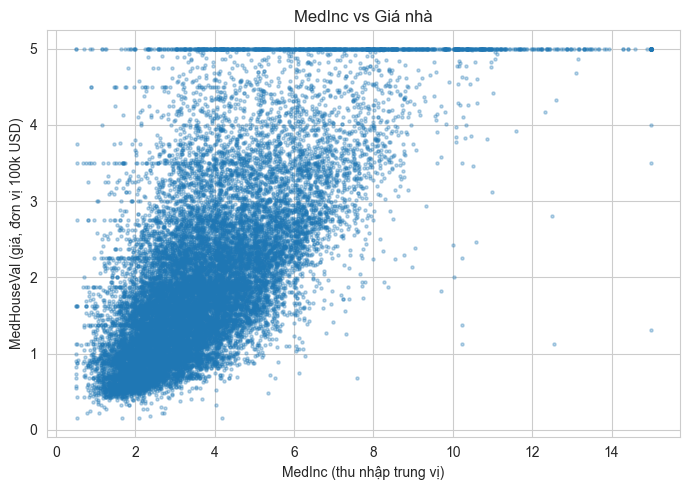

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], s=5, alpha=0.3)
plt.xlabel("MedInc (thu nhập trung vị)")
plt.ylabel("MedHouseVal (giá, đơn vị 100k USD)")
plt.title("MedInc vs Giá nhà")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "scatter_medinc.png"), dpi=120)
plt.show()

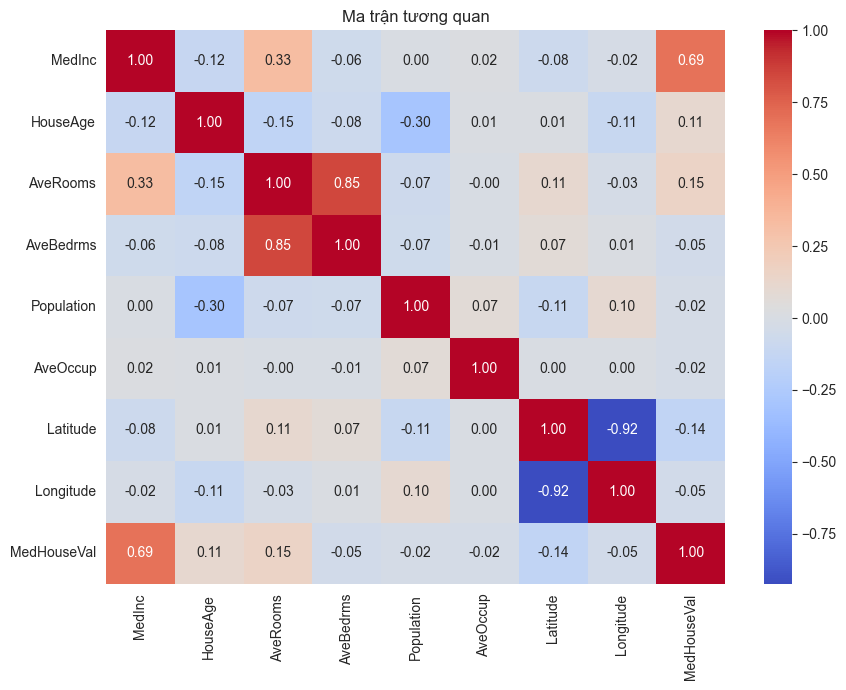

In [6]:
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "heatmap_correlation.png"), dpi=120)
plt.show()

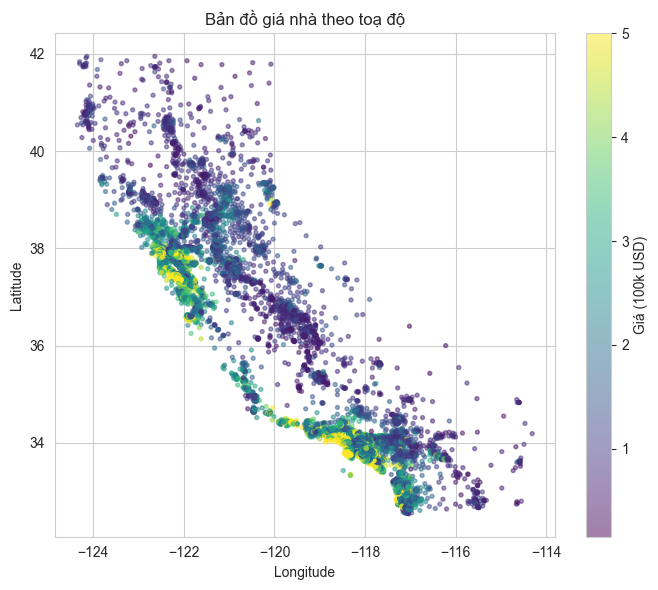

In [7]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"],
                  cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Giá (100k USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bản đồ giá nhà theo toạ độ")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "ban_do_gia.png"), dpi=120)
plt.show()

## 4. Kiểm tra 4 giả định hồi quy tuyến tính

① Tuyến tính — xem scatter/residual plot bên dưới.
② Độc lập — các quan sát là các khu vực dân cư khác nhau, giả định hợp lý.
③ Phương sai đều — sẽ kiểm tra bằng residual vs fitted plot (mục 8).
④ Sai số chuẩn — kiểm tra bằng Q-Q plot (mục 9).

## 5. Xử lý outlier & Feature Engineering

In [8]:
df_clean = df.copy()
for col in ["AveRooms", "AveBedrms", "AveOccup", "Population"]:
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=upper)

# rooms_per_household
df_clean["rooms_per_household"] = df_clean["AveRooms"] / df_clean["AveOccup"].replace(0, np.nan)
df_clean["rooms_per_household"] = df_clean["rooms_per_household"].fillna(df_clean["rooms_per_household"].median())

# Khoảng cách tới San Francisco / Los Angeles (toạ độ là phi tuyến với giá)
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437
df_clean["dist_to_SF"] = np.sqrt((df_clean["Latitude"] - sf_lat) ** 2 + (df_clean["Longitude"] - sf_lon) ** 2)
df_clean["dist_to_LA"] = np.sqrt((df_clean["Latitude"] - la_lat) ** 2 + (df_clean["Longitude"] - la_lon) ** 2)
df_clean["dist_to_nearest_city"] = df_clean[["dist_to_SF", "dist_to_LA"]].min(axis=1)

feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population",
                 "AveOccup", "Latitude", "Longitude",
                 "rooms_per_household", "dist_to_nearest_city"]
X = df_clean[feature_cols]
y = df_clean["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(16512, 10) (4128, 10)


## 6. Baseline

In [9]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_model(name, y_true, y_pred, store=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mp = mape(y_true, y_pred)
    print(f"[{name}] RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  MAPE={mp:.2f}%")
    row = {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mp}
    if store is not None:
        store.append(row)
    return row

results = []
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
eval_model("Baseline (mean)", y_test, dummy.predict(X_test), results)

[Baseline (mean)] RMSE=1.1449  MAE=0.9061  R2=-0.0002  MAPE=62.89%


{'model': 'Baseline (mean)',
 'RMSE': np.float64(1.1448563543099792),
 'MAE': 0.9060685490007149,
 'R2': -0.00021908714592466794,
 'MAPE': np.float64(62.8861496325994)}

## 7. Linear Regression cơ bản

In [10]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LinearRegression()),
])
pipe.fit(X_train, y_train)
y_pred_lr = pipe.predict(X_test)
eval_model("Linear Regression", y_test, y_pred_lr, results)

[Linear Regression] RMSE=0.6617  MAE=0.4805  R2=0.6658  MAPE=29.12%


{'model': 'Linear Regression',
 'RMSE': np.float64(0.6617362308924084),
 'MAE': 0.48053914220949284,
 'R2': 0.6658334561599819,
 'MAPE': np.float64(29.116089047799736)}

## 8. Residual Plot ⭐ (kiểm tra phương sai đều)

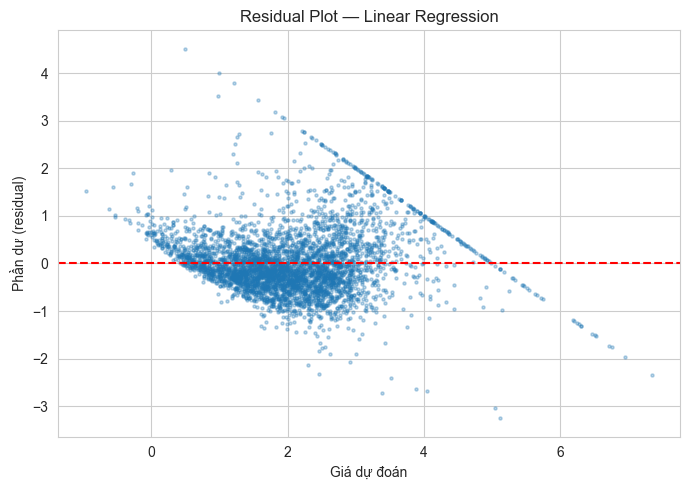

Nhận xét: nếu residual có hình phễu (loe rộng khi giá tăng) → dấu hiệu heteroscedasticity,
vi phạm giả định phương sai đều — cân nhắc dự đoán log(giá).


In [11]:
residuals = y_test - y_pred_lr
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_lr, residuals, s=5, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Giá dự đoán")
plt.ylabel("Phần dư (residual)")
plt.title("Residual Plot — Linear Regression")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "residual_plot.png"), dpi=120)
plt.show()
print("Nhận xét: nếu residual có hình phễu (loe rộng khi giá tăng) → dấu hiệu heteroscedasticity,")
print("vi phạm giả định phương sai đều — cân nhắc dự đoán log(giá).")

## 9. Q-Q Plot (kiểm tra phân phối chuẩn của phần dư)

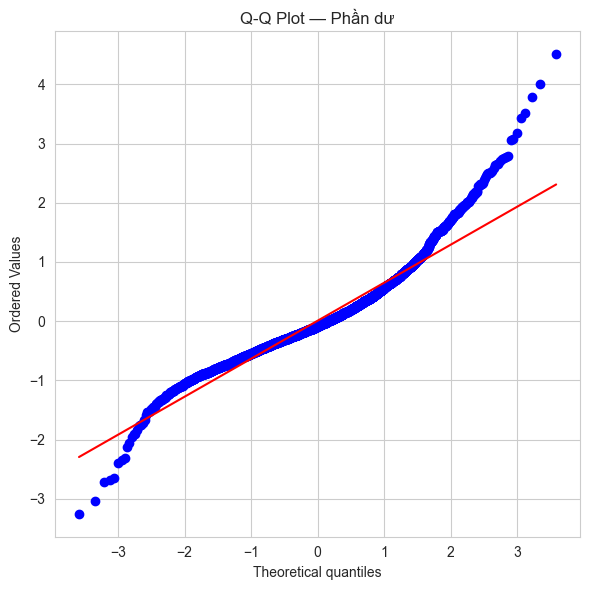

In [12]:
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot — Phần dư")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "qq_plot.png"), dpi=120)
plt.show()

## 10. Thử dự đoán log(giá)

[Linear Regression (log target)] RMSE=0.6967  MAE=0.4620  R2=0.6296  MAPE=25.50%


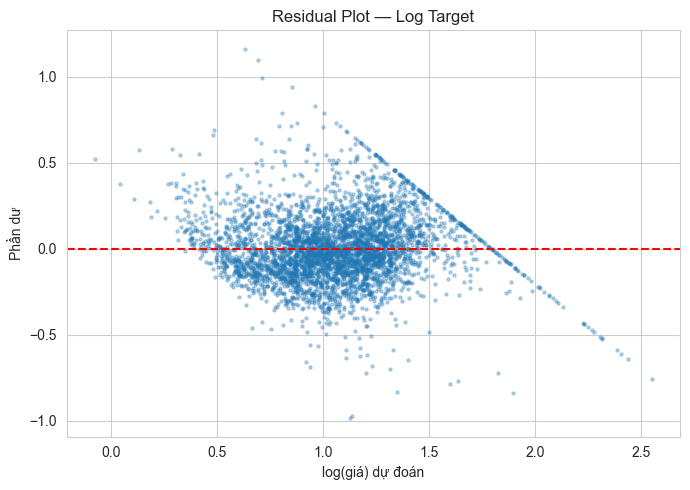

In [13]:
y_train_log = np.log1p(y_train.clip(lower=0))
y_test_log = np.log1p(y_test.clip(lower=0))

pipe_log = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LinearRegression()),
])
pipe_log.fit(X_train, y_train_log)
y_pred_log = pipe_log.predict(X_test)
y_pred_log_back = np.expm1(y_pred_log)
eval_model("Linear Regression (log target)", y_test, y_pred_log_back, results)

residuals_log = y_test_log - y_pred_log
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_log, residuals_log, s=5, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("log(giá) dự đoán")
plt.ylabel("Phần dư")
plt.title("Residual Plot — Log Target")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "residual_plot_log.png"), dpi=120)
plt.show()

## 11. Kiểm tra đa cộng tuyến (VIF)

In [14]:
X_vif = X_train.copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data.to_csv(os.path.join(REPORTS_DIR, "vif_table.csv"), index=False)
vif_data

,feature,VIF
8,rooms_per_household,12.073864
6,Latitude,11.612087
7,Longitude,10.714089
2,AveRooms,8.120273
5,AveOccup,5.642400
0,MedInc,3.262133
3,AveBedrms,2.034162
9,dist_to_nearest_city,1.814347
1,HouseAge,1.409493
4,Population,1.230695


## 12. Bảng hệ số đã chuẩn hoá + diễn giải

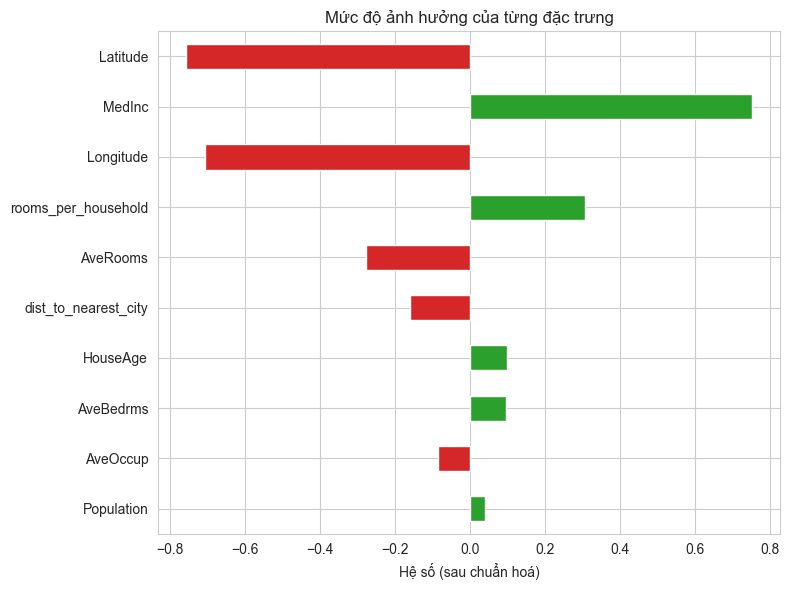

Latitude               -0.755518
MedInc                  0.750825
Longitude              -0.705720
rooms_per_household     0.307528
AveRooms               -0.277670
dist_to_nearest_city   -0.158812
HouseAge                0.097663
AveBedrms               0.097436
AveOccup               -0.085627
Population              0.039154
dtype: float64

In [15]:
he_so = pd.Series(pipe["lr"].coef_, index=X.columns).sort_values(key=abs, ascending=False)
he_so.to_csv(os.path.join(REPORTS_DIR, "he_so.csv"))

plt.figure(figsize=(8, 6))
he_so.plot(kind="barh", color=["#d62728" if v < 0 else "#2ca02c" for v in he_so])
plt.xlabel("Hệ số (sau chuẩn hoá)")
plt.title("Mức độ ảnh hưởng của từng đặc trưng")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "he_so.png"), dpi=120)
plt.show()
he_so

**Diễn giải nghiệp vụ (3 yếu tố ảnh hưởng mạnh nhất — điền lại theo kết quả chạy thực tế):**
1. `MedInc` — thu nhập trung vị khu vực có ảnh hưởng dương mạnh nhất tới giá nhà.
2. Vĩ độ/kinh độ (vị trí địa lý) — ảnh hưởng đáng kể, phản ánh chênh lệch giá giữa các vùng.
3. Các đặc trưng phòng ốc (`AveRooms`, `rooms_per_household`) — ảnh hưởng nhỏ hơn so với thu nhập và vị trí.

> Lưu ý: đây là hệ số tương quan trong mô hình tuyến tính, **không** khẳng định quan hệ nhân quả.

## 13. So sánh với Ridge (TT-12) và Random Forest (TT-17)

In [16]:
ridge = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge.fit(X_train, y_train)
eval_model("Ridge", y_test, ridge.predict(X_test), results)

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
eval_model("Random Forest", y_test, rf.predict(X_test), results)

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(REPORTS_DIR, "model_comparison.csv"), index=False)
results_df

[Ridge] RMSE=0.6617  MAE=0.4805  R2=0.6658  MAPE=29.12%
[Random Forest] RMSE=0.4717  MAE=0.3027  R2=0.8302  MAPE=17.04%


,model,RMSE,MAE,R2,MAPE
0,Baseline (mean),1.144856,0.906069,-0.000219,62.886150
1,Linear Regression,0.661736,0.480539,0.665833,29.116089
2,Linear Regression (log target),0.696698,0.462041,0.629591,25.500585
3,Ridge,0.661736,0.480541,0.665834,29.115229
4,Random Forest,0.471705,0.302703,0.830201,17.036619


**Nhận xét:** chênh lệch R² giữa Random Forest và Linear Regression chính là
**cái giá của tính giải thích được** — Linear Regression cho phép đọc trực tiếp
từng hệ số, trong khi Random Forest là hộp đen, độ chính xác cao hơn nhưng khó giải thích
cho khách hàng "vì sao hệ thống định giá vậy".

## 14. Lưu model

In [17]:
joblib.dump(pipe, os.path.join(MODELS_DIR, "lr_pipeline.joblib"))
print("Đã lưu model tại:", os.path.join(MODELS_DIR, "lr_pipeline.joblib"))

Đã lưu model tại: ../models\lr_pipeline.joblib


## 15. Hạn chế của mô hình

- Nhãn `MedHouseVal` bị cắt ngọn tại 5.0 (500k USD) → model không dự đoán được phân khúc nhà đắt hơn ngưỡng này.
- Quan hệ giữa toạ độ (Latitude/Longitude) và giá là **phi tuyến** → mô hình tuyến tính bắt kém quan hệ này,
  dù đã thêm đặc trưng khoảng cách tới trung tâm để cải thiện phần nào.
- `AveRooms`, `AveOccup` từng có outlier cực đoan (lỗi dữ liệu) đã được clip theo phân vị 99 trước khi huấn luyện.
- Hệ số hồi quy chỉ phản ánh **tương quan**, không phải quan hệ nhân quả.